Practical list submission by shreyansh kumar singh , bsc physical science with cs, 2238111,22036582053

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.metrics import silhouette_score

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
RANDOM_STATE = 42

def regression_eval(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'R2': r2}


def classification_stats(y_true, y_pred, y_score=None):
    # y_score: probability / decision function for AUC
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred)
    auc = None
    if y_score is not None:
        try:
            auc = roc_auc_score(y_true, y_score)
        except Exception:
            auc = None
    return {
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Accuracy': acc, 'Error': err, 'Recall': rec, 'Specificity': spec,
        'Precision': prec, 'F1': f1, 'AUC': auc
    }


def print_dict(d):
    for k, v in d.items():
        print(f"{k}: {v}")

#for regression
reg_data = load_diabetes()
X_reg = pd.DataFrame(reg_data.data, columns=reg_data.feature_names)
y_reg = pd.Series(reg_data.target, name='target')

# Classification dataset
clf_data = load_breast_cancer()
X_clf = pd.DataFrame(clf_data.data, columns=clf_data.feature_names)
y_clf = pd.Series(clf_data.target, name='target')

# Simple multiclass dataset for KNN/DecisionTree examples
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name='target')


In [ ]:
# Regression split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
# Classification split (breast cancer)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE)

# Standard scaling for models that need it
scaler_reg = StandardScaler().fit(Xr_train)
Xr_train_s = scaler_reg.transform(Xr_train)
Xr_test_s = scaler_reg.transform(Xr_test)

scaler_clf = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_clf.transform(Xc_train)
Xc_test_s = scaler_clf.transform(Xc_test)

In [ ]:
#Naive Bayes Classifier
nb = GaussianNB()
nb.fit(Xc_train_s, yc_train)
nb_pred = nb.predict(Xc_test_s)
nb_proba = nb.predict_proba(Xc_test_s)[:,1]
nb_stats = classification_stats(yc_test, nb_pred, y_score=nb_proba)
print('\nNaive Bayes Classification metrics:')
print_dict(nb_stats)


Naive Bayes Classification metrics:
TP: 70
TN: 40
FP: 3
FN: 1
Accuracy: 0.9649122807017544
Error: 0.03508771929824561
Recall: 0.9859154929577465
Specificity: 0.9302325581395349
Precision: 0.958904109589041
F1: 0.9722222222222222
AUC: 0.9973796265967901


In [ ]:
#Simple Linear Regression
lr_simple = LinearRegression()
Xr_train_one = Xr_train_s[:, [0]]
Xr_test_one = Xr_test_s[:, [0]]
lr_simple.fit(Xr_train_one, yr_train)
y_pred_lr_simple = lr_simple.predict(Xr_test_one)
print('\nSimple Linear Regression metrics:')
print_dict(regression_eval(yr_test, y_pred_lr_simple))

lr_multi = LinearRegression()
lr_multi.fit(Xr_train_s, yr_train)
y_pred_lr_multi = lr_multi.predict(Xr_test_s)
print('\nMultiple Linear Regression metrics:')
print_dict(regression_eval(yr_test, y_pred_lr_multi))


Simple Linear Regression metrics:
MSE: 5254.231976236004
R2: 0.008289640305771506

Multiple Linear Regression metrics:
MSE: 2900.1936284934823
R2: 0.45260276297191926


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
Xr_train_poly = poly.fit_transform(Xr_train_s)
Xr_test_poly = poly.transform(Xr_test_s)
poly_reg = LinearRegression()
poly_reg.fit(Xr_train_poly, yr_train)
y_pred_poly = poly_reg.predict(Xr_test_poly)
print('\nPolynomial Regression (degree=2) metrics:')
print_dict(regression_eval(yr_test, y_pred_poly))


Polynomial Regression (degree=2) metrics:
MSE: 3096.0283073442783
R2: 0.4156399336407989


In [ ]:
lasso = Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)

lasso.fit(Xr_train_s, yr_train)
y_pred_lasso = lasso.predict(Xr_test_s)
print('\nLasso Regression metrics:')
print_dict(regression_eval(yr_test, y_pred_lasso))

ridge.fit(Xr_train_s, yr_train)
y_pred_ridge = ridge.predict(Xr_test_s)
print('\nRidge Regression metrics:')
print_dict(regression_eval(yr_test, y_pred_ridge))


Lasso Regression metrics:
MSE: 2884.6242887352123
R2: 0.45554139902790414

Ridge Regression metrics:
MSE: 2892.0145657501726
R2: 0.45414652070698225


In [ ]:
#Logistic Regression
logreg = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
logreg.fit(Xc_train_s, yc_train)
log_pred = logreg.predict(Xc_test_s)
log_proba = logreg.predict_proba(Xc_test_s)[:,1]
log_stats = classification_stats(yc_test, log_pred, y_score=log_proba)
print('\nLogistic Regression metrics:')
print_dict(log_stats)


Logistic Regression metrics:
TP: 70
TN: 41
FP: 2
FN: 1
Accuracy: 0.9736842105263158
Error: 0.02631578947368418
Recall: 0.9859154929577465
Specificity: 0.9534883720930233
Precision: 0.9722222222222222
F1: 0.9790209790209791
AUC: 0.99737962659679


In [ ]:
#Artificial Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(50,25), max_iter=1000, random_state=RANDOM_STATE)
mlp.fit(Xc_train_s, yc_train)
mlp_pred = mlp.predict(Xc_test_s)
try:
    mlp_proba = mlp.predict_proba(Xc_test_s)[:,1]
except Exception:
    mlp_proba = None
mlp_stats = classification_stats(yc_test, mlp_pred, y_score=mlp_proba)
print('\nANN (MLPClassifier) metrics:')
print_dict(mlp_stats)


ANN (MLPClassifier) metrics:
TP: 70
TN: 41
FP: 2
FN: 1
Accuracy: 0.9736842105263158
Error: 0.02631578947368418
Recall: 0.9859154929577465
Specificity: 0.9534883720930233
Precision: 0.9722222222222222
F1: 0.9790209790209791
AUC: 0.9941041598427777


In [ ]:
#K-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_train_s, yc_train)
knn_pred = knn.predict(Xc_test_s)
knn_proba = knn.predict_proba(Xc_test_s)[:,1]
knn_stats = classification_stats(yc_test, knn_pred, y_score=knn_proba)
print('\nK-NN Classification metrics:')
print_dict(knn_stats)


K-NN Classification metrics:
TP: 68
TN: 40
FP: 3
FN: 3
Accuracy: 0.9473684210526315
Error: 0.052631578947368474
Recall: 0.9577464788732394
Specificity: 0.9302325581395349
Precision: 0.9577464788732394
F1: 0.9577464788732394
AUC: 0.9819849328529315


In [ ]:
#Decision tree classification
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(Xc_train_s, yc_train)
dt_pred = dt.predict(Xc_test_s)
try:
    dt_proba = dt.predict_proba(Xc_test_s)[:,1]
except Exception:
    dt_proba = None
dt_stats = classification_stats(yc_test, dt_pred, y_score=dt_proba)
print('\nDecision Tree Classification metrics:')
print_dict(dt_stats)



Decision Tree Classification metrics:
TP: 68
TN: 40
FP: 3
FN: 3
Accuracy: 0.9473684210526315
Error: 0.052631578947368474
Recall: 0.9577464788732394
Specificity: 0.9302325581395349
Precision: 0.9577464788732394
F1: 0.9577464788732394
AUC: 0.9439895185063871


In [ ]:
#SVM classification
# Use probability=True to get probabilities for AUC
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm.fit(Xc_train_s, yc_train)
svm_pred = svm.predict(Xc_test_s)
svm_proba = svm.predict_proba(Xc_test_s)[:,1]
svm_stats = classification_stats(yc_test, svm_pred, y_score=svm_proba)
print('\nSVM Classification metrics:')
print_dict(svm_stats)



SVM Classification metrics:
TP: 71
TN: 41
FP: 2
FN: 0
Accuracy: 0.9824561403508771
Error: 0.01754385964912286
Recall: 1.0
Specificity: 0.9534883720930233
Precision: 0.9726027397260274
F1: 0.9861111111111112
AUC: 0.99737962659679



KMeans clustering:
Inertia: 78.85566582597727
Silhouette score: 0.551191604619592

Hierarchical clustering:
Silhouette score: 0.5543236611296419


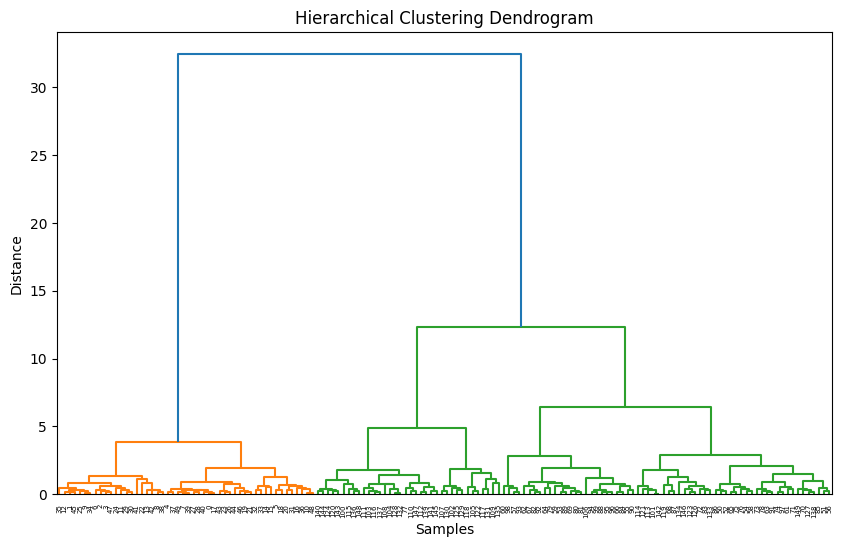

In [ ]:
#K-means clustering
# We'll use the Iris dataset for clustering as an example
X_cluster = X_iris.values
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X_cluster)
km_inertia = kmeans.inertia_
km_silhouette = silhouette_score(X_cluster, km_labels)
print('\nKMeans clustering:')
print(f'Inertia: {km_inertia}')
print(f'Silhouette score: {km_silhouette}')

#Hierarchical clustering
Z = linkage(X_cluster, method='ward')
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_cluster)
hc_silhouette = silhouette_score(X_cluster, hc_labels)
print('\nHierarchical clustering:')
print(f'Silhouette score: {hc_silhouette}')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [ ]:
#Cross-validation (k-fold)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Example: cross-validate multiple linear regression (scoring with neg_mean_squared_error)
cv_results_lr = cross_validate(LinearRegression(), X_reg, y_reg, cv=kf, scoring=('neg_mean_squared_error', 'r2'), return_train_score=False)
print('\nCross-validation results for Multiple Linear Regression:')
print('MSEs (neg):', cv_results_lr['test_neg_mean_squared_error'])
print('R2s:', cv_results_lr['test_r2'])

# Example: cross-validate Logistic Regression
cv_results_log = cross_validate(LogisticRegression(max_iter=10000), X_clf, y_clf, cv=kf, scoring=('accuracy', 'precision', 'recall', 'f1'), return_train_score=False)
print('\nCross-validation results for Logistic Regression:')
print('Accuracies:', cv_results_log['test_accuracy'])
print('Precisions:', cv_results_log['test_precision'])
print('Recalls:', cv_results_log['test_recall'])
print('F1s:', cv_results_log['test_f1'])

results = {
    'Model': ['NaiveBayes','LogisticRegression','KNN','DecisionTree','SVM','MLP'],
    'Accuracy':[nb_stats['Accuracy'], log_stats['Accuracy'], knn_stats['Accuracy'], dt_stats['Accuracy'], svm_stats['Accuracy'], mlp_stats['Accuracy']],
    'AUC':[nb_stats['AUC'], log_stats['AUC'], knn_stats['AUC'], dt_stats['AUC'], svm_stats['AUC'], mlp_stats['AUC']]
}
results_df = pd.DataFrame(results)
print('\nSummary classification results:')
print(results_df)


Cross-validation results for Multiple Linear Regression:
MSEs (neg): [-2900.19362849 -2662.63760862 -3312.30588884 -2797.88355256
 -3403.88779293]
R2s: [0.45260276 0.57320015 0.39144785 0.58428888 0.39081186]

Cross-validation results for Logistic Regression:
Accuracies: [0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Precisions: [0.94594595 0.98666667 0.93243243 0.97222222 0.92647059]
Recalls: [0.98591549 0.96103896 0.97183099 0.98591549 0.94029851]
F1s: [0.96551724 0.97368421 0.95172414 0.97902098 0.93333333]

Summary classification results:
                Model  Accuracy       AUC
0          NaiveBayes  0.964912  0.997380
1  LogisticRegression  0.973684  0.997380
2                 KNN  0.947368  0.981985
3        DecisionTree  0.947368  0.943990
4                 SVM  0.982456  0.997380
5                 MLP  0.973684  0.994104
